In [1]:
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from sklearn.decomposition import PCA, TruncatedSVD, FastICA
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Task 1
In this subtask, I trained a small Word2Vec model on a toy dataset following the Gensim tutorial. I then applied PCA to reduce the word vectors to two dimensions and visualized them in a scatter plot with word annotations.

In [2]:
from gensim.models import Word2Vec

# define training data
sentences = [['this', 'is', 'the', 'first', 'sentence', 'for', 'word2vec'],
            ['this', 'is', 'the', 'second', 'sentence'],
            ['yet', 'another', 'sentence'],
            ['one', 'more', 'sentence'],
            ['and', 'the', 'final', 'sentence']]

# train model
model = Word2Vec(sentences, min_count=1) # min_count=1 to include all words, even those that appear only once

# summarize the loaded model
print(model)

# summarize vocabulary
words = list(model.wv.key_to_index)
print(words)

# access vector for one word
print(model.wv['sentence'])

# save model
model.save('model.bin')

# load model
new_model = Word2Vec.load('model.bin')

print(new_model)

Word2Vec<vocab=14, vector_size=100, alpha=0.025>
['sentence', 'the', 'is', 'this', 'final', 'and', 'more', 'one', 'another', 'yet', 'second', 'word2vec', 'for', 'first']
[-5.3622725e-04  2.3643136e-04  5.1033497e-03  9.0092728e-03
 -9.3029495e-03 -7.1168090e-03  6.4588725e-03  8.9729885e-03
 -5.0154282e-03 -3.7633716e-03  7.3805046e-03 -1.5334714e-03
 -4.5366134e-03  6.5540518e-03 -4.8601604e-03 -1.8160177e-03
  2.8765798e-03  9.9187379e-04 -8.2852151e-03 -9.4488179e-03
  7.3117660e-03  5.0702621e-03  6.7576934e-03  7.6286553e-04
  6.3508903e-03 -3.4053659e-03 -9.4640139e-04  5.7685734e-03
 -7.5216377e-03 -3.9361035e-03 -7.5115822e-03 -9.3004224e-04
  9.5381187e-03 -7.3191668e-03 -2.3337686e-03 -1.9377411e-03
  8.0774371e-03 -5.9308959e-03  4.5162440e-05 -4.7537340e-03
 -9.6035507e-03  5.0072931e-03 -8.7595852e-03 -4.3918253e-03
 -3.5099984e-05 -2.9618145e-04 -7.6612402e-03  9.6147433e-03
  4.9820580e-03  9.2331432e-03 -8.1579173e-03  4.4957981e-03
 -4.1370760e-03  8.2453608e-04  8.498

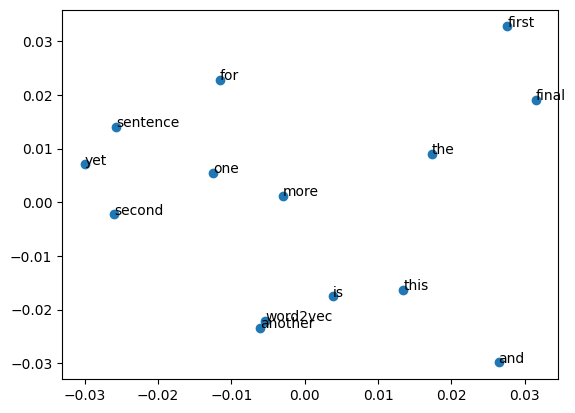

In [3]:
# fit a 2d PCA model to the vectors
X = model.wv[model.wv.key_to_index]
pca = PCA(n_components=2)
result = pca.fit_transform(X)

# create a scatter plot of the projection
plt.scatter(result[:, 0], result[:, 1])
words = list(model.wv.key_to_index)
for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))
plt.show()

# Task 2

In [4]:
filename = 'GoogleNews-vectors-negative300.60k.word2vec.txt'
model_google = KeyedVectors.load_word2vec_format(filename, binary=False)

result = model_google.most_similar(positive=['company', 'employee'], negative=['employer'], topn=10)
for word, score in result:
    print(f"Test 1: {word}: {score}")

result2 = model_google.most_similar(positive=['immigrant', 'undocumented'], negative=['documented'], topn=10)
for word, score in result2:
    print(f"Test 2: {word}: {score}")

result3 = model_google.most_similar(positive=['school', 'teacher'], negative=['student'], topn=10)
for word, score in result3:
    print(f"Test 3: {word}: {score}")

Test 1: subsidiary: 0.4462946653366089
Test 1: companywide: 0.4433775842189789
Test 1: customer: 0.44120314717292786
Test 1: Company: 0.4376986026763916
Test 1: firm: 0.4370129406452179
Test 1: regulatory_filing: 0.4342222809791565
Test 1: employees: 0.42013487219810486
Test 1: corporation: 0.41906407475471497
Test 1: business: 0.4169084131717682
Test 1: Inc.: 0.4159269332885742
Test 2: immigrants: 0.7232161164283752
Test 2: illegal_immigrant: 0.7046064138412476
Test 2: illegal_immigrants: 0.6763535737991333
Test 2: undocumented_immigrants: 0.6563877463340759
Test 2: undocumented_workers: 0.6302635669708252
Test 2: illegal_alien: 0.6226015090942383
Test 2: Immigrant: 0.5916497707366943
Test 2: immigration: 0.5884267091751099
Test 2: illegal_aliens: 0.5875353217124939
Test 2: illegals: 0.5857043266296387
Test 3: elementary: 0.7351497411727905
Test 3: teachers: 0.6516027450561523
Test 3: guidance_counselor: 0.6155742406845093
Test 3: elementary_schools: 0.6131370663642883
Test 3: schools

In [5]:
filename2 = "glove.6B.100d.60k.word2vec.txt"
model_glove = KeyedVectors.load_word2vec_format(filename2, binary=False)

result = model_glove.most_similar(positive=['company', 'employee'], negative=['employer'], topn=10)
for word, score in result:
    print(f"Test 1: {word}: {score}")

result2 = model_glove.most_similar(positive=['immigrant', 'undocumented'], negative=['documented'], topn=10)
for word, score in result2:
    print(f"Test 2: {word}: {score}")

result3 = model_glove.most_similar(positive=['school', 'teacher'], negative=['student'], topn=10)
for word, score in result3:
    print(f"Test 3: {word}: {score}")


Test 1: inc.: 0.7085356116294861
Test 1: co.: 0.6967877745628357
Test 1: unit: 0.6951483488082886
Test 1: management: 0.6858863234519958
Test 1: corp.: 0.6637009382247925
Test 1: firm: 0.6614362597465515
Test 1: subsidiary: 0.6592209339141846
Test 1: business: 0.6570724248886108
Test 1: marketing: 0.6552150249481201
Test 1: recently: 0.6453567743301392
Test 2: immigrants: 0.7142198085784912
Test 2: migrant: 0.6629659533500671
Test 2: migrants: 0.6347675323486328
Test 2: illegals: 0.6205036044120789
Test 2: unemployed: 0.5894306898117065
Test 2: mexicans: 0.5738041400909424
Test 2: immigration: 0.5283385515213013
Test 2: unskilled: 0.5183451771736145
Test 2: farmworkers: 0.5089523792266846
Test 2: expatriates: 0.5072649717330933
Test 3: elementary: 0.737051248550415
Test 3: taught: 0.7299442291259766
Test 3: teaching: 0.7199927568435669
Test 3: college: 0.6988298892974854
Test 3: instructor: 0.6662430167198181
Test 3: schools: 0.6464500427246094
Test 3: kindergarten: 0.6373058557510376


Using the GoogleNews Word2Vec model, the similarity tests show a strong sensitivity to contextual and domain-specific usage. In the first test, the model returns organizational terms such as subsidiary, companywide, and firm, suggesting a focus on corporate structure. In the second test, terms related to undocumented immigration (illegal_immigrant, undocumented_workers) are retrieved, reflecting how immigration is framed in news discourse. In the third test, the results (elementary, teachers, schools) clearly capture the educational domain.

With the GloVe embeddings, the results appear more lexically oriented and stable. In the company-related test, the model returns abbreviations and organizational labels such as inc., corp., and co.. In the immigration test, GloVe retrieves more general population-related terms (immigrants, migrants, unemployed), with less emphasis on legal framing. In the education-related test, the model highlights teaching-related actions and roles (teaching, taught, instructor).

Overall, both models produce meaningful similarities, but they differ in focus. GoogleNews Word2Vec tends to emphasize contextual and discourse-driven associations, while GloVe captures more general lexical and structural relations. Based on these examples, neither model is clearly superior; instead, they reflect different properties of their training data and objectives.

# Task 3

In [ ]:
tests = [
    ['bank', 'money', 'loan', 'river'],
    ['apple', 'google', 'microsoft', 'orange'],
    ['paper', 'pen', 'book', 'computer'],
    ['doctor', 'nurse', 'hospital', 'teacher'],
    ['train', 'bus', 'car', 'road'],
    ['python', 'java', 'snake', 'code'],
    ['light', 'dark', 'heavy', 'bright'],
    ['head', 'arm', 'leg', 'chair'],
    ['cold', 'hot', 'warm', 'winter'],
    ['music', 'song', 'sound', 'noise']
]


for t in tests:
    print("Google:", model_google.doesnt_match(t))
    print("GloVe:", model_glove.doesnt_match(t))

Google: river
GloVe: river
Google: google
GloVe: orange
Google: computer
GloVe: computer
Google: teacher
GloVe: teacher
Google: road
GloVe: road
Google: code
GloVe: snake
Google: heavy
GloVe: heavy
Google: chair
GloVe: leg
Google: hot
GloVe: winter
Google: noise
GloVe: noise


The results suggest that the GoogleNews Word2Vec embeddings are strongly influenced by the contextual environments in which words appear. As a consequence, the model sometimes fails to separate terms that belong to different literal domains. For instance, snake is not clearly separated from python, and google is selected as the odd one out in the set apple – orange – google – microsoft, indicating that apple is often interpreted as a fruit rather than as a company.

A similar effect can be observed in the set cold – warm – hot – winter, where hot is treated differently due to its frequent metaphorical usage in news texts, which distances it from its literal temperature-related meaning.

In contrast, GloVe embeddings appear to rely more on stable and literal semantic relationships, leading to what is, in most cases, the intuitively expected choice of the odd word out. This suggests that GloVe captures lexical meaning in a more domain-consistent way, while GoogleNews Word2Vec emphasizes discourse-level and contextual associations.

# Task 4

In [7]:
# Display first 5 lines of each file to understand their differences
with open(filename, "r", encoding="utf-8", errors="ignore") as f:
    for i in range(15):
        print(f.readline().strip())

with open(filename2, "r", encoding="utf-8", errors="ignore") as f:
    for i in range(15):
        print(f.readline().strip()) 

60000 300
</s> 0.0011291504 -0.00089645386 0.00031852722 0.0015335083 0.0011062622 -0.0014038086 -3.0517578e-05 -0.0004196167 -0.0005760193 0.0010757446 -0.0010223389 -0.00061798096 -0.00075531006 0.0014038086 -0.0016403198 -0.00063323975 0.0016326904 -0.0010070801 -0.0012664795 0.00065231323 -0.000415802 -0.0010757446 0.0015258789 -0.0002746582 0.00014019012 0.0015716553 0.0013580322 -0.000831604 -0.0014038086 0.0015792847 0.00025367737 -0.0007324219 -0.00010538101 -0.0011672974 0.0015792847 0.00065612793 -0.0006599426 2.9206276e-06 0.0011291504 0.0004272461 -0.00037002563 -0.0011520386 0.0012664795 -3.516674e-06 0.00026512146 -0.00040245056 0.0001411438 -3.361702e-05 0.00075912476 -0.0005187988 -7.104874e-05 0.00060272217 -0.00050735474 -0.001625061 -0.00043678284 -0.0009918213 -0.0012207031 -0.00032234192 6.866455e-05 -0.0011672974 -0.00051116943 0.001411438 0.00033569336 -0.0004749298 -0.001373291 0.00036621094 -0.0014419556 -0.00060653687 0.0008010864 0.0011291504 -0.0008354187 -0

By inspecting the first lines of the pretrained embedding files, clear structural differences emerge between the two models. Both vocabularies contain 60,000 words, but the GoogleNews Word2Vec embeddings use 300-dimensional vectors, whereas the GloVe embeddings use 100-dimensional vectors.

Differences can also be observed in the vocabulary construction. The GoogleNews model includes special tokens such as `</s>`. In contrast, the GloVe vocabulary includes punctuation symbols and both lowercase and capitalized forms (e.g. the and The), suggesting a different treatment of text normalization.

These differences in dimensionality, preprocessing, and vocabulary composition may help explain the behavioral differences observed in the previous tasks.

# Task 5

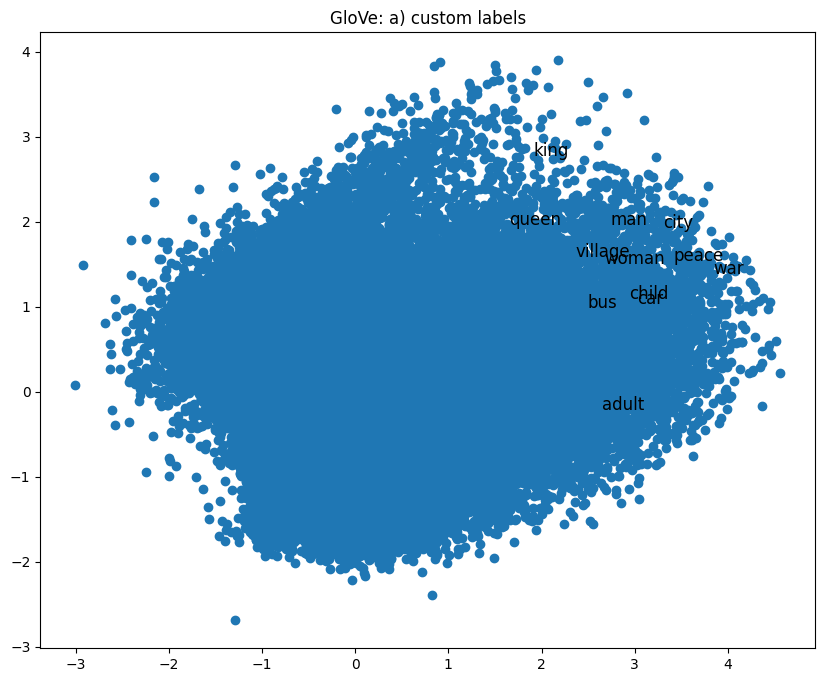

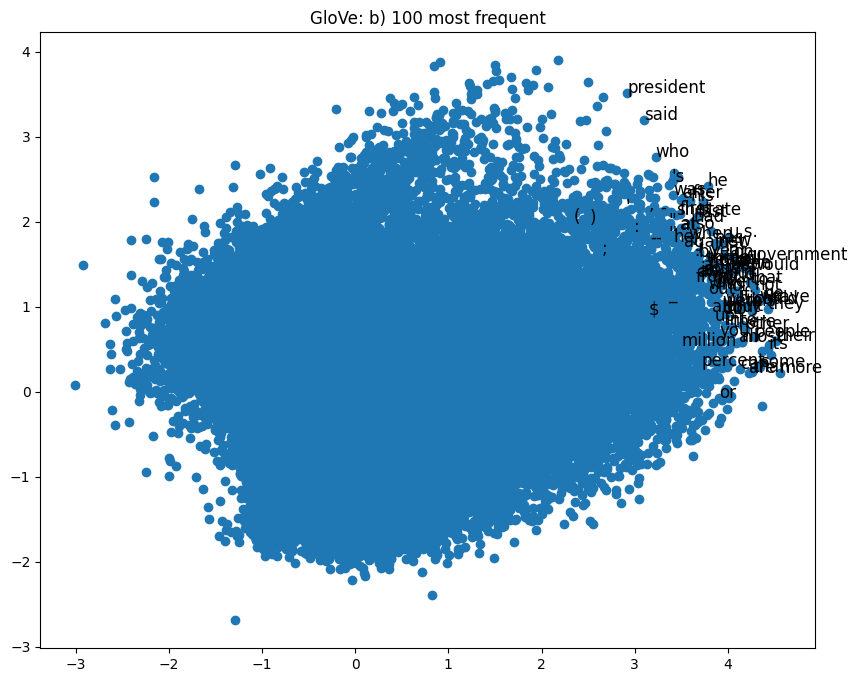

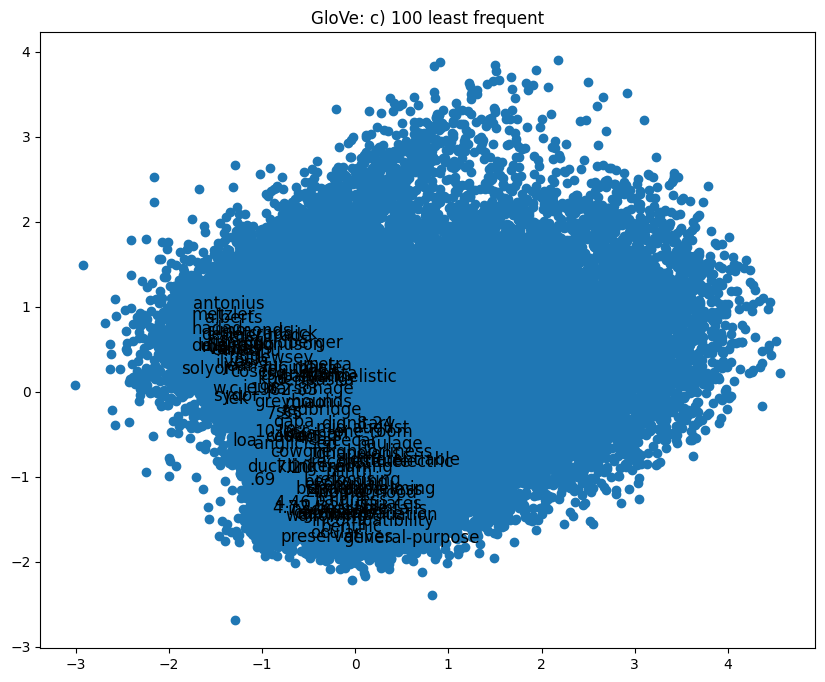

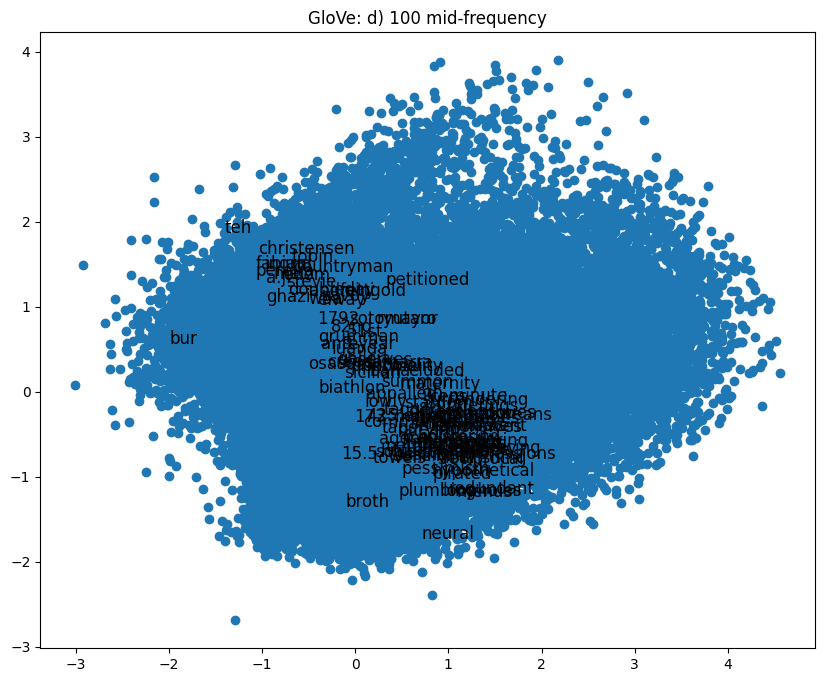

In [ ]:
pca_glove = PCA(n_components=2)
X_glove = model_glove[model_glove.key_to_index]
result_glove = pca_glove.fit_transform(X_glove)

words_glove = list(model_glove.key_to_index.keys())
annotation_a = ['man', 'woman', 'king', 'queen', 'child', 'adult', 'city', 'village', 'car', 'bus', 'war', 'peace']
annotation_b = words_glove[:100] # most frequent 100 words
annotation_c = words_glove[-100:] # least frequent 100 words
annotation_d = words_glove[19800:19900] # middle frequency words

def plot_annotations_glove(result, words, annotations, title):
    plt.figure(figsize=(10, 8))
    plt.scatter(result[:, 0], result[:, 1])
    for word in annotations:
        idx = model_glove.key_to_index.get(word)
        if idx is not None:
            plt.annotate(word, xy=(result[idx, 0], result[idx, 1]), fontsize=12)
    plt.title(title)
    plt.show()

plot_annotations_glove(result_glove, words_glove, annotation_a, "GloVe: a) custom labels")
plot_annotations_glove(result_glove, words_glove, annotation_b, "GloVe: b) 100 most frequent")
plot_annotations_glove(result_glove, words_glove, annotation_c, "GloVe: c) 100 least frequent")
plot_annotations_glove(result_glove, words_glove, annotation_d, "GloVe: d) 100 mid-frequency")
        



# Task 6

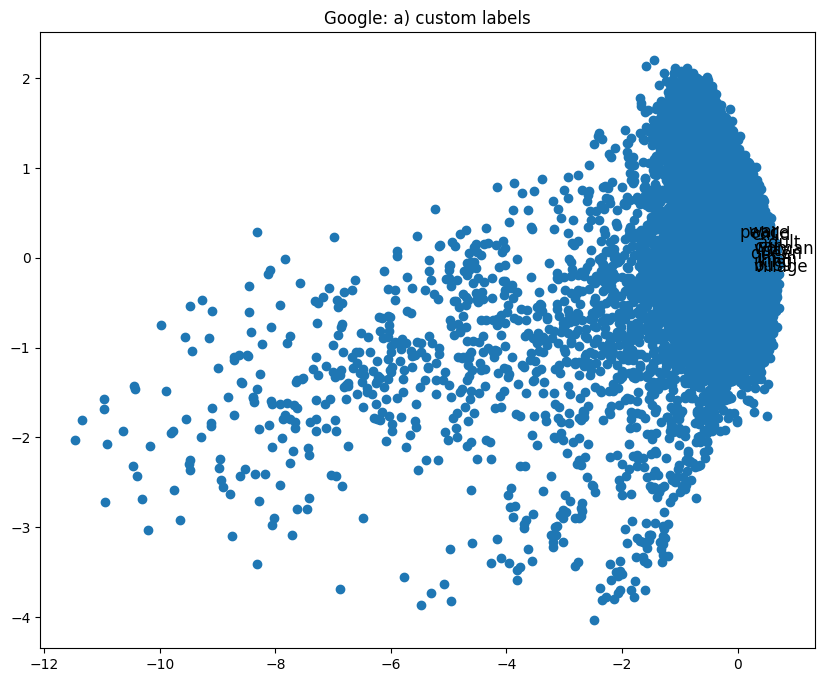

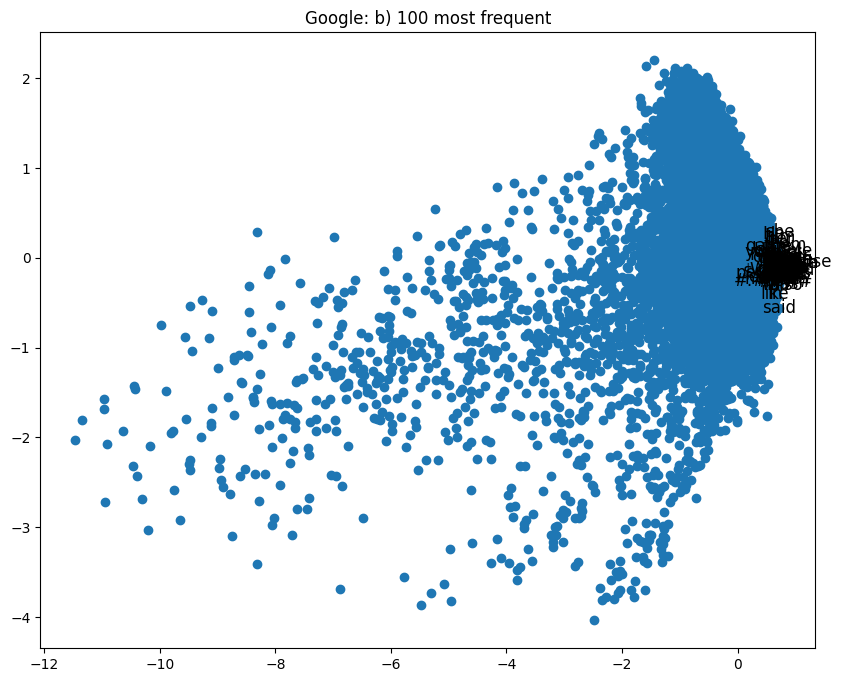

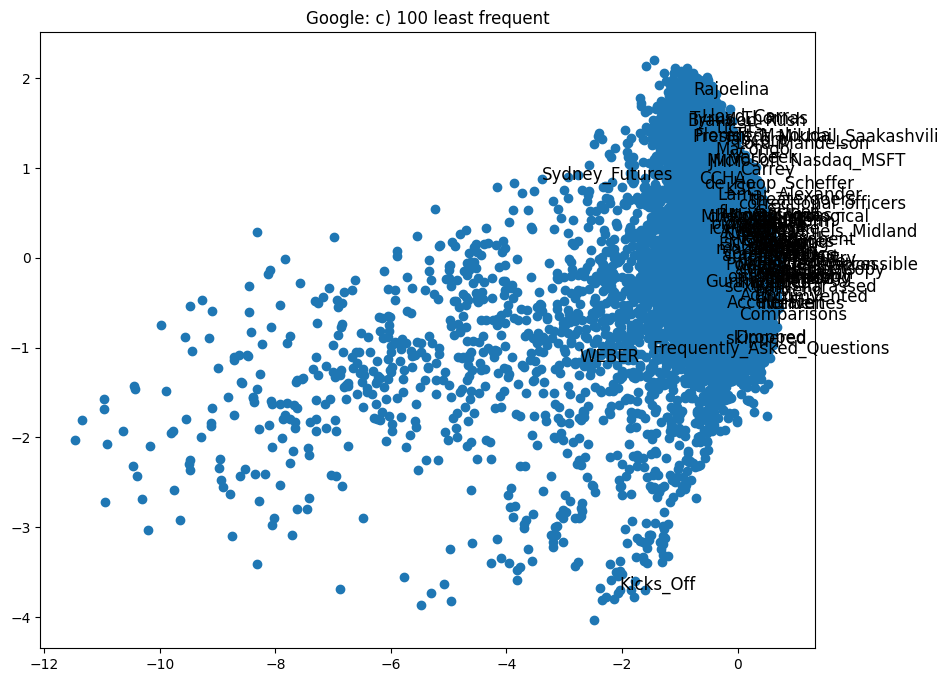

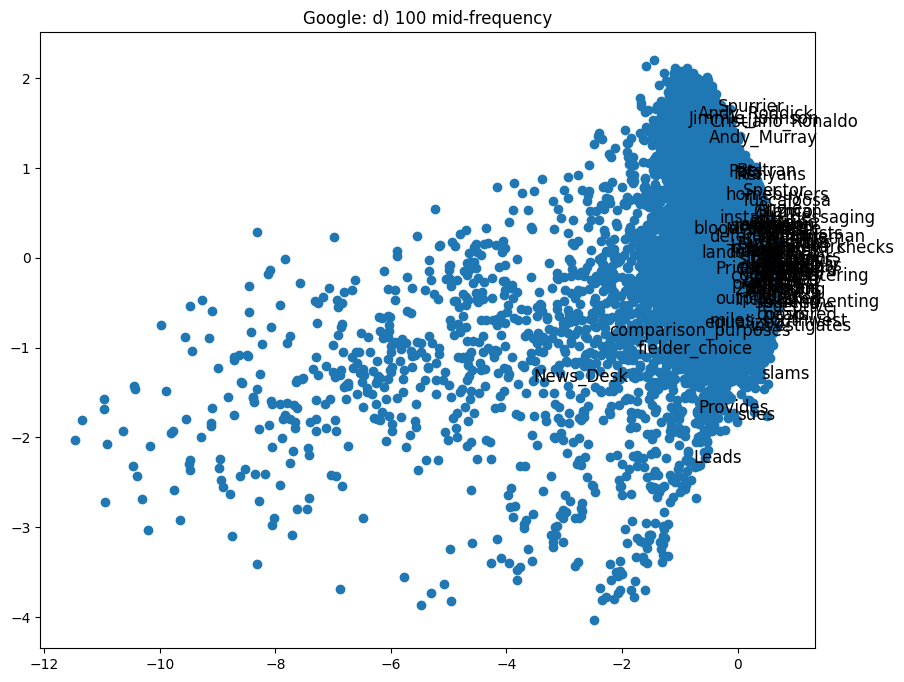

In [7]:
pca_google = PCA(n_components=2)
X_google = model_google[model_google.key_to_index]
result_google = pca_google.fit_transform(X_google)

words_google = list(model_google.key_to_index.keys())
annotation_a = ['man', 'woman', 'king', 'queen', 'child', 'adult', 'city', 'village', 'car', 'bus', 'war', 'peace']
annotation_b = words_google[:100]
annotation_c = words_google[-100:]
annotation_d = words_google[19800:19900]

def plot_annotations_google(result, words, annotations, title):
    plt.figure(figsize=(10, 8))
    plt.scatter(result[:, 0], result[:, 1])
    for word in annotations:
        idx = model_google.key_to_index.get(word)
        if idx is not None:
            plt.annotate(word, xy=(result[idx, 0], result[idx, 1]), fontsize=12)
    plt.title(title)
    plt.show()

plot_annotations_google(result_google, words_google, annotation_a, "Google: a) custom labels")
plot_annotations_google(result_google, words_google, annotation_b, "Google: b) 100 most frequent")
plot_annotations_google(result_google, words_google, annotation_c, "Google: c) 100 least frequent")
plot_annotations_google(result_google, words_google, annotation_d, "Google: d) 100 mid-frequency")

### GloVe vs GoogleNews

- **Selected words:**  
In both models, some clear semantic relations can be observed (e.g. *car–bus*, *man–king*).  
In GloVe, these words are generally placed close to each other in a clear way.  
In Google Word2Vec, some related words are also close, but others are farther apart, suggesting that usage context influences their position more strongly.

- **Most frequent words:**  
In GloVe, the most frequent words form a compact and central cluster, mainly consisting of grammatical words.  
In Google Word2Vec, frequent words are more related to the news domain and appear more compressed and overlapping.

- **Least frequent words:**  
In both models, rare words are scattered across the space and show little visible structure.

- **Mid-frequency words:**  
GloVe shows a relatively smooth and balanced organization for mid-frequency words.  
Google Word2Vec instead shows groups that seem more related to specific topics.

### Final consideration
Overall, GloVe produces a more regular and easy-to-interpret embedding space.  
Google Word2Vec appears more influenced by the training corpus and focuses more on contextual usage than on general semantic similarity.


# Task 7

In [12]:
dim_red_PCA = PCA(n_components=30)
dim_red_SVD = TruncatedSVD(n_components=30, random_state=42)
dim_red_ICA = FastICA(n_components=30, random_state=42)

google_reduced_PCA = dim_red_PCA.fit_transform(X_google)
google_reduced_SVD = dim_red_SVD.fit_transform(X_google)    
google_reduced_ICA = dim_red_ICA.fit_transform(X_google)

glove_reduced_PCA = dim_red_PCA.fit_transform(X_glove)
glove_reduced_SVD = dim_red_SVD.fit_transform(X_glove)  
glove_reduced_ICA = dim_red_ICA.fit_transform(X_glove)

n_top = 6000
google_vecsPCA = google_reduced_PCA[:n_top]
glove_vecsPCA  = glove_reduced_PCA[:n_top]
google_vecsSVD = google_reduced_SVD[:n_top]
glove_vecsSVD  = glove_reduced_SVD[:n_top]
google_vecsICA = google_reduced_ICA[:n_top]
glove_vecsICA  = glove_reduced_ICA[:n_top]

google_words = words_google[:n_top]
glove_words  = words_glove[:n_top]

# check shapes
print("Google PCA shape:", google_vecsPCA.shape)
print("GloVe PCA shape:", glove_vecsPCA.shape)
print("Google SVD shape:", google_vecsSVD.shape)
print("GloVe SVD shape:", glove_vecsSVD.shape)
print("Google ICA shape:", google_vecsICA.shape)
print("GloVe ICA shape:", glove_vecsICA.shape)

Google PCA shape: (6000, 30)
GloVe PCA shape: (6000, 30)
Google SVD shape: (6000, 30)
GloVe SVD shape: (6000, 30)
Google ICA shape: (6000, 30)
GloVe ICA shape: (6000, 30)


In [16]:
# For each dimension in PCA-reduced Google and GloVe vectors, print top 10 and bottom 10 words
dims_to_display = range(5)  # Number of dimensions to display because displaying all 30 may be too much
for dim in dims_to_display:
    values_googlePCA = google_vecsPCA[:, dim]
    top_idxs_googlePCA = np.argsort(values_googlePCA)[-10:]
    bottom_idxs_googlePCA = np.argsort(values_googlePCA)[:10]

    print("Top google words for dimension", dim, ":", [google_words[i] for i in top_idxs_googlePCA])
    print("Bottom google words for dimension", dim, ":", [google_words[i] for i in bottom_idxs_googlePCA])
print()

for dim in dims_to_display:
    values_glovePCA = glove_vecsPCA[:, dim]
    top_idxs_glovePCA = np.argsort(values_glovePCA)[-10:]
    bottom_idxs_glovePCA = np.argsort(values_glovePCA)[:10]

    print("Top glove words for dimension", dim, ":", [glove_words[i] for i in top_idxs_glovePCA])
    print("Bottom glove words for dimension", dim, ":", [glove_words[i] for i in bottom_idxs_glovePCA])

Top google words for dimension 0 : ['apparently', 'his', 'Bruce', 'himself', 'explained', 'became', 'the', 'whose', 'finds', 'describes']
Bottom google words for dimension 0 : ['differ_materially', 'looking_statements', 'Announces', 'Writer', 'AP_Photo', '3_pointer', '#.##_ERA', 'free_throws', 'please_visit', 'homer']
Top google words for dimension 1 : ['Palestinians', 'White_Sox', 'Red_Sox', 'Saddam', 'Dodgers', 'Mets', 'Hamas', 'BJP', 'Phillies', 'Federer']
Bottom google words for dimension 1 : ['Announces', 'AP_Photo', 'please_visit', '###-####', '###-###-####', 'Writer', 'Photo', 'joins', 'headquartered', 'Contact']
Top google words for dimension 2 : ['regime', 'Muslims', 'militants', 'parliamentary', 'diplomatic', 'central_bank', 'democratic', 'democracy', 'prime_minister', 'parliament']
Bottom google words for dimension 2 : ['Announces', '###-####', '###-###-####', 'Ave', 'Louisville', 'Madison', 'AP_Photo', 'Indianapolis', 'Austin', 'Oklahoma']
Top google words for dimension 3 :

In [17]:
# Repeat for SVD 
for dim in dims_to_display:
    values_googleSVD = google_vecsSVD[:, dim]
    top_idxs_googleSVD = np.argsort(values_googleSVD)[-10:]
    bottom_idxs_googleSVD = np.argsort(values_googleSVD)[:10]

    print("Top google words for dimension", dim, ":", [google_words[i] for i in top_idxs_googleSVD])
    print("Bottom google words for dimension", dim, ":", [google_words[i] for i in bottom_idxs_googleSVD])
print()

for dim in dims_to_display:
    values_gloveSVD = glove_vecsSVD[:, dim]
    top_idxs_gloveSVD = np.argsort(values_gloveSVD)[-10:]
    bottom_idxs_gloveSVD = np.argsort(values_gloveSVD)[:10]

    print("Top glove words for dimension", dim, ":", [glove_words[i] for i in top_idxs_gloveSVD])
    print("Bottom glove words for dimension", dim, ":", [glove_words[i] for i in bottom_idxs_gloveSVD])

Top google words for dimension 0 : ['explained', 'Although', 'While', 'specialist', 'newly', 'recently', 'Meanwhile', 'whose', 'According', '</s>']
Bottom google words for dimension 0 : ['differ_materially', 'looking_statements', 'Writer', '#.##_ERA', '3_pointer', 'Federer', 'free_throws', 'AP_Photo', 'homer', 'homers']
Top google words for dimension 1 : ['#:##.##', 'headquartered', 'differ_materially', 'looking_statements', '###-###-####', '###-####', 'Writer', 'please_visit', 'AP_Photo', 'Announces']
Bottom google words for dimension 1 : ['Federer', 'Saddam', 'Palin', 'Phillies', 'Red_Sox', 'Mets', 'Bonds', 'Steelers', 'NASCAR', 'Dodgers']
Top google words for dimension 2 : ['Charlie', 'dressed', 'laugh', 'Photo', 'Announces', 'crazy', 'loved', 'Ave', 'loves', 'AP_Photo']
Bottom google words for dimension 2 : ['looking_statements', 'BJP', 'Nasdaq', 'central_bank', 'currencies', 'differ_materially', 'Hamas', 'Standard_&', 'yen', 'yuan']
Top google words for dimension 3 : ['terrorists'

In [18]:
# Repeat for ICA as needed
for dim in dims_to_display:
    values_googleICA = google_vecsICA[:, dim]
    top_idxs_googleICA = np.argsort(values_googleICA)[-10:]
    bottom_idxs_googleICA = np.argsort(values_googleICA)[:10]

    print("Top google words for dimension", dim, ":", [google_words[i] for i in top_idxs_googleICA])
    print("Bottom google words for dimension", dim, ":", [google_words[i] for i in bottom_idxs_googleICA])
print()

for dim in dims_to_display:
    values_gloveICA = glove_vecsICA[:, dim]
    top_idxs_gloveICA = np.argsort(values_gloveICA)[-10:]
    bottom_idxs_gloveICA = np.argsort(values_gloveICA)[:10]

    print("Top glove words for dimension", dim, ":", [glove_words[i] for i in top_idxs_gloveICA])
    print("Bottom glove words for dimension", dim, ":", [glove_words[i] for i in bottom_idxs_gloveICA])

Top google words for dimension 0 : ['Miami', 'New_York', 'Stock_Exchange', 'Birmingham', 'NY', 'offices', 'Manhattan', 'headquarters', 'Boston', 'Philadelphia']
Bottom google words for dimension 0 : ['species', 'wildlife', 'Alaska', 'fishing', 'conservation', 'drought', 'forest', 'fish', 'Idaho', 'mining']
Top google words for dimension 1 : ['crime', 'District_Court', 'suicide', 'tragedy', 'unprecedented', 'fatal', 'accident', 'Based', 'Test', 'crash']
Bottom google words for dimension 1 : ['foods', 'meat', 'flowers', 'sugar', 'milk', 'meal', 'bags', 'coffee', 'bottle', 'meals']
Top google words for dimension 2 : ['Toronto', 'hockey', 'Canada', 'Canadians', 'NHL', 'Ottawa', 'Montreal', 'Quebec', 'Vancouver', 'puck']
Bottom google words for dimension 2 : ['Alabama', 'Arkansas', 'LSU', 'Mississippi', 'Tennessee', 'Memphis', 'Kentucky', 'NC', 'County_Sheriff', 'Oklahoma']
Top google words for dimension 3 : ['Residents', 'implementation', 'procedures', 'requirements', 'provision', 'process

### Conclusion
Overall, google news embeddings tend to encode topic- and domain-specific information driven by news discourse (e.g. politics, sports, finance), whereas GloVe embeddings show more abstract and linguistically structured dimensions, often separating grammatical, emotional, and conceptual aspects of meaning.

PCA and SVD give very similar results and produce dimensions that are relatively easy to interpret from a semantic point of view. ICA, instead, tends to generate noisier dimensions, which are harder to interpret.